# Objetivo
Este notebook tem como objetivo a exploração de dados relacionados a gestão de estoque e pedidos de um mercado coletados no Kaggle, a fim de identificar informações relevantes para possíveis atualizações no aplicativo e suas funcionalidades e melhorias na estruturação do banco de dados.

# Importação das bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import seaborn as sns

C:\Users\brunogalvao-ieg\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\brunogalvao-ieg\AppData\Roaming\Python\Python311\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.3)
  from scipy.stats import gaussian_kde


#### Configurando tamanhos de display de dataframes

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Carregando dataset diretamente do Kaggle

### [Link do Dataset](https://www.kaggle.com/datasets/salahuddinahmedshuvo/grocery-inventory-and-sales-dataset)

### Dicionário das colunas do dataset
Product_ID: Identificador para cada produto.

Product_Name: Nome do produto.

Category: Categoria do produto (ex: Grains & Pulses, Beverages, Fruits & Vegetables).

Supplier_ID: Identificador do fornecedor do produto.

Supplier_Name: Nome do fornecedor.

Stock_Quantity: O nível de estoque do produto no inventário.

Reorder_Level: O novo nível de estoque que deve ser pedido. 

Reorder_Quantity: A quantidade do produto a ser pedido quando o estoque atingir o "reorder level".

Unit_Price: Preço por unidade do produto.

Date_Received: A data que o produto foi recebido no inventário.

Last_Order_Date: A última data que o produto foi pedido. 

Expiration_Date: Data de expiração/validade do produto, se aplicável.

Warehouse_Location: Endereço do inventário onde o produto está armazenado. 

Sales_Volume: Número total de unidades vendidas.

Inventory_Turnover_Rate: A taxa na qual o produto é vendido e reabastecido.

Status: Status atual do produto (ex: Active, Discontinued, Backordered).

In [3]:
# Carregando os datasets diretamente dentro de um Pandas dataframe
df = kagglehub.dataset_load(
    kagglehub.KaggleDatasetAdapter.PANDAS,
    "salahuddinahmedshuvo/grocery-inventory-and-sales-dataset",
    "Grocery_Inventory_and_Sales_Dataset.csv"
)

print("Quantidade de linhas: ", df.shape[0])
print("Quantidade de colunas: ", df.shape[1])
df.head()

Quantidade de linhas:  990
Quantidade de colunas:  16


,Product_ID,Product_Name,Catagory,Supplier_ID,Supplier_Name,Stock_Quantity,Reorder_Level,Reorder_Quantity,Unit_Price,Date_Received,Last_Order_Date,Expiration_Date,Warehouse_Location,Sales_Volume,Inventory_Turnover_Rate,Status
0,29-205-1132,Sushi Rice,Grains & Pulses,38-037-1699,Jaxnation,22,72,70,$4.50,8/16/2024,6/29/2024,9/19/2024,48 Del Sol Trail,32,19,Discontinued
1,40-681-9981,Arabica Coffee,Beverages,54-470-2479,Feedmix,45,77,2,$20.00,11/1/2024,5/29/2024,5/8/2024,36 3rd Place,85,1,Discontinued
2,06-955-3428,Black Rice,Grains & Pulses,54-031-2945,Vinder,30,38,83,$6.00,8/3/2024,6/10/2024,9/22/2024,3296 Walton Court,31,34,Backordered
3,71-594-6552,Long Grain Rice,Grains & Pulses,63-492-7603,Brightbean,12,59,62,$1.50,12/8/2024,2/19/2025,4/17/2024,3 Westerfield Crossing,95,99,Active
4,57-437-1828,Plum,Fruits & Vegetables,54-226-4308,Topicstorm,37,30,74,$4.00,7/3/2024,10/11/2024,10/5/2024,15068 Scoville Court,62,25,Backordered


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 990 entries, 0 to 989
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Product_ID               990 non-null    object
 1   Product_Name             990 non-null    object
 2   Catagory                 989 non-null    object
 3   Supplier_ID              990 non-null    object
 4   Supplier_Name            990 non-null    object
 5   Stock_Quantity           990 non-null    int64 
 6   Reorder_Level            990 non-null    int64 
 7   Reorder_Quantity         990 non-null    int64 
 8   Unit_Price               990 non-null    object
 9   Date_Received            990 non-null    object
 10  Last_Order_Date          990 non-null    object
 11  Expiration_Date          990 non-null    object
 12  Warehouse_Location       990 non-null    object
 13  Sales_Volume             990 non-null    int64 
 14  Inventory_Turnover_Rate  990 non-null    i

In [5]:
df.dropna()

,Product_ID,Product_Name,Catagory,Supplier_ID,Supplier_Name,Stock_Quantity,Reorder_Level,Reorder_Quantity,Unit_Price,Date_Received,Last_Order_Date,Expiration_Date,Warehouse_Location,Sales_Volume,Inventory_Turnover_Rate,Status
0,29-205-1132,Sushi Rice,Grains & Pulses,38-037-1699,Jaxnation,22,72,70,$4.50,8/16/2024,6/29/2024,9/19/2024,48 Del Sol Trail,32,19,Discontinued
1,40-681-9981,Arabica Coffee,Beverages,54-470-2479,Feedmix,45,77,2,$20.00,11/1/2024,5/29/2024,5/8/2024,36 3rd Place,85,1,Discontinued
2,06-955-3428,Black Rice,Grains & Pulses,54-031-2945,Vinder,30,38,83,$6.00,8/3/2024,6/10/2024,9/22/2024,3296 Walton Court,31,34,Backordered
3,71-594-6552,Long Grain Rice,Grains & Pulses,63-492-7603,Brightbean,12,59,62,$1.50,12/8/2024,2/19/2025,4/17/2024,3 Westerfield Crossing,95,99,Active
4,57-437-1828,Plum,Fruits & Vegetables,54-226-4308,Topicstorm,37,30,74,$4.00,7/3/2024,10/11/2024,10/5/2024,15068 Scoville Court,62,25,Backordered
5,21-120-6238,All-Purpose Flour,Grains & Pulses,86-292-4587,Dabjam,55,33,14,$1.75,12/3/2024,5/26/2024,9/5/2024,050 Mcbride Avenue,34,62,Discontinued
6,71-516-1996,Corn Oil,Oils & Fats,04-391-7610,Tagfeed,96,52,16,$2.50,3/18/2024,5/7/2024,6/20/2024,12 Truax Court,67,13,Active
7,39-629-5554,Egg (Goose),Dairy,67-679-4930,Muxo,44,90,17,$2.50,2/3/2025,4/9/2024,2/5/2025,267 International Plaza,21,91,Discontinued
8,66-268-8345,Greek Yogurt,Dairy,32-182-1895,Thoughtstorm,91,84,11,$3.00,12/4/2024,6/2/2024,1/8/2025,550 Clemons Plaza,56,90,Active
9,46-452-9419,Egg (Duck),Dairy,67-137-4215,Wordify,43,10,15,$1.00,11/18/2024,11/14/2024,7/8/2024,55782 Welch Hill,27,69,Active


In [6]:
display(df.columns.to_list())

['Product_ID',
 'Product_Name',
 'Catagory',
 'Supplier_ID',
 'Supplier_Name',
 'Stock_Quantity',
 'Reorder_Level',
 'Reorder_Quantity',
 'Unit_Price',
 'Date_Received',
 'Last_Order_Date',
 'Expiration_Date',
 'Warehouse_Location',
 'Sales_Volume',
 'Inventory_Turnover_Rate',
 'Status']

## Excluindo colunas não relevantes

In [7]:
colunas_para_remover = ["Warehouse_Location"]

df.drop(colunas_para_remover, axis=1, inplace=True)

display(df.head(5))

,Product_ID,Product_Name,Catagory,Supplier_ID,Supplier_Name,Stock_Quantity,Reorder_Level,Reorder_Quantity,Unit_Price,Date_Received,Last_Order_Date,Expiration_Date,Sales_Volume,Inventory_Turnover_Rate,Status
0,29-205-1132,Sushi Rice,Grains & Pulses,38-037-1699,Jaxnation,22,72,70,$4.50,8/16/2024,6/29/2024,9/19/2024,32,19,Discontinued
1,40-681-9981,Arabica Coffee,Beverages,54-470-2479,Feedmix,45,77,2,$20.00,11/1/2024,5/29/2024,5/8/2024,85,1,Discontinued
2,06-955-3428,Black Rice,Grains & Pulses,54-031-2945,Vinder,30,38,83,$6.00,8/3/2024,6/10/2024,9/22/2024,31,34,Backordered
3,71-594-6552,Long Grain Rice,Grains & Pulses,63-492-7603,Brightbean,12,59,62,$1.50,12/8/2024,2/19/2025,4/17/2024,95,99,Active
4,57-437-1828,Plum,Fruits & Vegetables,54-226-4308,Topicstorm,37,30,74,$4.00,7/3/2024,10/11/2024,10/5/2024,62,25,Backordered


## Renomeando colunas

In [8]:
df.rename(columns={'Catagory': 'Category'}, inplace=True)
display(df.head(5))

,Product_ID,Product_Name,Category,Supplier_ID,Supplier_Name,Stock_Quantity,Reorder_Level,Reorder_Quantity,Unit_Price,Date_Received,Last_Order_Date,Expiration_Date,Sales_Volume,Inventory_Turnover_Rate,Status
0,29-205-1132,Sushi Rice,Grains & Pulses,38-037-1699,Jaxnation,22,72,70,$4.50,8/16/2024,6/29/2024,9/19/2024,32,19,Discontinued
1,40-681-9981,Arabica Coffee,Beverages,54-470-2479,Feedmix,45,77,2,$20.00,11/1/2024,5/29/2024,5/8/2024,85,1,Discontinued
2,06-955-3428,Black Rice,Grains & Pulses,54-031-2945,Vinder,30,38,83,$6.00,8/3/2024,6/10/2024,9/22/2024,31,34,Backordered
3,71-594-6552,Long Grain Rice,Grains & Pulses,63-492-7603,Brightbean,12,59,62,$1.50,12/8/2024,2/19/2025,4/17/2024,95,99,Active
4,57-437-1828,Plum,Fruits & Vegetables,54-226-4308,Topicstorm,37,30,74,$4.00,7/3/2024,10/11/2024,10/5/2024,62,25,Backordered


## Checando nome das colunas

In [9]:
print(df.columns.tolist())

['Product_ID', 'Product_Name', 'Category', 'Supplier_ID', 'Supplier_Name', 'Stock_Quantity', 'Reorder_Level', 'Reorder_Quantity', 'Unit_Price', 'Date_Received', 'Last_Order_Date', 'Expiration_Date', 'Sales_Volume', 'Inventory_Turnover_Rate', 'Status']


## Tratando dados nulos

In [10]:
df = df.dropna(how='all', ignore_index=True) # Excluindo todas as linhas que são inteiramente nulas
df.head()

,Product_ID,Product_Name,Category,Supplier_ID,Supplier_Name,Stock_Quantity,Reorder_Level,Reorder_Quantity,Unit_Price,Date_Received,Last_Order_Date,Expiration_Date,Sales_Volume,Inventory_Turnover_Rate,Status
0,29-205-1132,Sushi Rice,Grains & Pulses,38-037-1699,Jaxnation,22,72,70,$4.50,8/16/2024,6/29/2024,9/19/2024,32,19,Discontinued
1,40-681-9981,Arabica Coffee,Beverages,54-470-2479,Feedmix,45,77,2,$20.00,11/1/2024,5/29/2024,5/8/2024,85,1,Discontinued
2,06-955-3428,Black Rice,Grains & Pulses,54-031-2945,Vinder,30,38,83,$6.00,8/3/2024,6/10/2024,9/22/2024,31,34,Backordered
3,71-594-6552,Long Grain Rice,Grains & Pulses,63-492-7603,Brightbean,12,59,62,$1.50,12/8/2024,2/19/2025,4/17/2024,95,99,Active
4,57-437-1828,Plum,Fruits & Vegetables,54-226-4308,Topicstorm,37,30,74,$4.00,7/3/2024,10/11/2024,10/5/2024,62,25,Backordered


In [11]:
print("Quantidade de colunas:", df.shape[1])

# Verificando onde está os nulos
df.isna().sum()

Quantidade de colunas: 15


Product_ID                 0
Product_Name               0
Category                   1
Supplier_ID                0
Supplier_Name              0
Stock_Quantity             0
Reorder_Level              0
Reorder_Quantity           0
Unit_Price                 0
Date_Received              0
Last_Order_Date            0
Expiration_Date            0
Sales_Volume               0
Inventory_Turnover_Rate    0
Status                     0
dtype: int64

In [12]:
# Verificando o que tá nulo na coluna category
df[df['Category'].isnull()]

,Product_ID,Product_Name,Category,Supplier_ID,Supplier_Name,Stock_Quantity,Reorder_Level,Reorder_Quantity,Unit_Price,Date_Received,Last_Order_Date,Expiration_Date,Sales_Volume,Inventory_Turnover_Rate,Status
685,10-378-9729,Cabbage,NaN,83-941-9620,Rooxo,69,21,68,$66.55,12/23/2024,11/26/2024,9/21/2024,36,35,Discontinued


In [13]:
# Analisando produtos com o mesmo nome
df[df['Product_Name'] == 'Cabbage']

,Product_ID,Product_Name,Category,Supplier_ID,Supplier_Name,Stock_Quantity,Reorder_Level,Reorder_Quantity,Unit_Price,Date_Received,Last_Order_Date,Expiration_Date,Sales_Volume,Inventory_Turnover_Rate,Status
23,67-025-1245,Cabbage,Fruits & Vegetables,28-575-0716,Chatterbridge,88,46,55,$1.00,4/9/2024,3/6/2024,8/12/2024,73,63,Active
501,21-013-3508,Cabbage,Fruits & Vegetables,64-489-8494,Meevee,12,95,49,$1.00,6/9/2024,6/13/2024,11/10/2024,25,23,Backordered
521,79-428-8753,Cabbage,Fruits & Vegetables,29-521-7910,Skivee,62,79,95,$1.00,5/16/2024,7/6/2024,12/30/2024,34,12,Active
652,45-380-4627,Cabbage,Fruits & Vegetables,20-201-5639,Zoombox,90,1,40,$0.90,10/20/2024,1/11/2025,2/16/2025,52,19,Discontinued
685,10-378-9729,Cabbage,NaN,83-941-9620,Rooxo,69,21,68,$66.55,12/23/2024,11/26/2024,9/21/2024,36,35,Discontinued
788,75-927-9108,Cabbage,Fruits & Vegetables,27-406-7972,Topdrive,24,32,17,$1.00,9/29/2024,6/17/2024,7/2/2024,55,72,Discontinued
806,82-538-4809,Cabbage,Fruits & Vegetables,74-357-2990,Twitternation,83,61,4,$1.00,9/16/2024,11/5/2024,10/24/2024,35,7,Backordered
987,31-745-6850,Cabbage,Fruits & Vegetables,96-215-2767,Lajo,94,90,12,$0.90,10/3/2024,10/24/2024,11/1/2024,98,71,Active


In [14]:
# Assumindo a category dos outros produtos
df['Category'].fillna('Fruits & Vegetables', inplace=True)
display(df.head(5))

C:\Users\brunogalvao-ieg\AppData\Local\Temp\ipykernel_9472\2159934557.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Category'].fillna('Fruits & Vegetables', inplace=True)


,Product_ID,Product_Name,Category,Supplier_ID,Supplier_Name,Stock_Quantity,Reorder_Level,Reorder_Quantity,Unit_Price,Date_Received,Last_Order_Date,Expiration_Date,Sales_Volume,Inventory_Turnover_Rate,Status
0,29-205-1132,Sushi Rice,Grains & Pulses,38-037-1699,Jaxnation,22,72,70,$4.50,8/16/2024,6/29/2024,9/19/2024,32,19,Discontinued
1,40-681-9981,Arabica Coffee,Beverages,54-470-2479,Feedmix,45,77,2,$20.00,11/1/2024,5/29/2024,5/8/2024,85,1,Discontinued
2,06-955-3428,Black Rice,Grains & Pulses,54-031-2945,Vinder,30,38,83,$6.00,8/3/2024,6/10/2024,9/22/2024,31,34,Backordered
3,71-594-6552,Long Grain Rice,Grains & Pulses,63-492-7603,Brightbean,12,59,62,$1.50,12/8/2024,2/19/2025,4/17/2024,95,99,Active
4,57-437-1828,Plum,Fruits & Vegetables,54-226-4308,Topicstorm,37,30,74,$4.00,7/3/2024,10/11/2024,10/5/2024,62,25,Backordered


### Resultado

In [15]:
# Sem dados nulos
df.isna().sum()

Product_ID                 0
Product_Name               0
Category                   0
Supplier_ID                0
Supplier_Name              0
Stock_Quantity             0
Reorder_Level              0
Reorder_Quantity           0
Unit_Price                 0
Date_Received              0
Last_Order_Date            0
Expiration_Date            0
Sales_Volume               0
Inventory_Turnover_Rate    0
Status                     0
dtype: int64

In [16]:
# Vendo novamente
df[df['Product_Name'] == 'Cabbage']

,Product_ID,Product_Name,Category,Supplier_ID,Supplier_Name,Stock_Quantity,Reorder_Level,Reorder_Quantity,Unit_Price,Date_Received,Last_Order_Date,Expiration_Date,Sales_Volume,Inventory_Turnover_Rate,Status
23,67-025-1245,Cabbage,Fruits & Vegetables,28-575-0716,Chatterbridge,88,46,55,$1.00,4/9/2024,3/6/2024,8/12/2024,73,63,Active
501,21-013-3508,Cabbage,Fruits & Vegetables,64-489-8494,Meevee,12,95,49,$1.00,6/9/2024,6/13/2024,11/10/2024,25,23,Backordered
521,79-428-8753,Cabbage,Fruits & Vegetables,29-521-7910,Skivee,62,79,95,$1.00,5/16/2024,7/6/2024,12/30/2024,34,12,Active
652,45-380-4627,Cabbage,Fruits & Vegetables,20-201-5639,Zoombox,90,1,40,$0.90,10/20/2024,1/11/2025,2/16/2025,52,19,Discontinued
685,10-378-9729,Cabbage,Fruits & Vegetables,83-941-9620,Rooxo,69,21,68,$66.55,12/23/2024,11/26/2024,9/21/2024,36,35,Discontinued
788,75-927-9108,Cabbage,Fruits & Vegetables,27-406-7972,Topdrive,24,32,17,$1.00,9/29/2024,6/17/2024,7/2/2024,55,72,Discontinued
806,82-538-4809,Cabbage,Fruits & Vegetables,74-357-2990,Twitternation,83,61,4,$1.00,9/16/2024,11/5/2024,10/24/2024,35,7,Backordered
987,31-745-6850,Cabbage,Fruits & Vegetables,96-215-2767,Lajo,94,90,12,$0.90,10/3/2024,10/24/2024,11/1/2024,98,71,Active


## Colunas de identificação

In [17]:
# Excluindo colunas que possuem muitos dados únicos, que por muitas das vezes são dados de identificação
for i in df:
    if len(df[i].value_counts()) >= 3000:
        df.drop(columns=[i], inplace=True)

# Analisando colunas que ficaram e quantos dados únicos possuem
print("Quantidade de colunas: ", df.shape[1])
for i in df:
    print('\n=====', i, ('====='))
    print(len(df[i].value_counts()))

Quantidade de colunas:  15

===== Product_ID =====
990

===== Product_Name =====
121

===== Category =====
7

===== Supplier_ID =====
990

===== Supplier_Name =====
350

===== Stock_Quantity =====
91

===== Reorder_Level =====
100

===== Reorder_Quantity =====
100

===== Unit_Price =====
112

===== Date_Received =====
351

===== Last_Order_Date =====
332

===== Expiration_Date =====
341

===== Sales_Volume =====
81

===== Inventory_Turnover_Rate =====
100

===== Status =====
3


## Analisando dados de cada coluna

In [18]:
for i in df:
    print('=====', i, ('====='))
    print(df[i].value_counts())

===== Product_ID =====
Product_ID
29-205-1132    1
40-681-9981    1
06-955-3428    1
71-594-6552    1
57-437-1828    1
21-120-6238    1
71-516-1996    1
39-629-5554    1
66-268-8345    1
46-452-9419    1
51-469-4611    1
42-220-9305    1
75-094-1179    1
11-073-0189    1
22-621-2774    1
39-449-0772    1
55-936-2406    1
82-041-7211    1
48-414-6162    1
76-854-0095    1
25-349-7974    1
66-627-9752    1
78-614-4402    1
67-025-1245    1
68-418-6724    1
40-795-0753    1
02-508-3777    1
79-741-0770    1
31-211-5803    1
16-499-5059    1
76-340-4432    1
38-732-7667    1
04-240-2226    1
79-136-9840    1
73-401-5721    1
91-848-0606    1
54-109-8062    1
70-612-2531    1
26-161-6692    1
43-893-5408    1
11-316-8405    1
34-086-3222    1
21-816-1004    1
43-693-2092    1
63-270-7076    1
90-230-9767    1
05-334-2923    1
52-481-5224    1
11-325-7396    1
70-854-6891    1
46-520-1819    1
91-105-7317    1
40-751-8635    1
02-920-4829    1
36-918-2937    1
68-761-6907    1
69-468-5468   

## Mudando tipos de dados

In [19]:
df['Unit_Price'] = df['Unit_Price'].replace('[\$,]', '', regex=True).astype(float)

In [20]:
df['Date_Received'] = pd.to_datetime(df['Date_Received'])
df['Last_Order_Date'] = pd.to_datetime(df['Last_Order_Date'])
df['Expiration_Date'] = pd.to_datetime(df['Expiration_Date'])

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 990 entries, 0 to 989
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Product_ID               990 non-null    object        
 1   Product_Name             990 non-null    object        
 2   Category                 990 non-null    object        
 3   Supplier_ID              990 non-null    object        
 4   Supplier_Name            990 non-null    object        
 5   Stock_Quantity           990 non-null    int64         
 6   Reorder_Level            990 non-null    int64         
 7   Reorder_Quantity         990 non-null    int64         
 8   Unit_Price               990 non-null    float64       
 9   Date_Received            990 non-null    datetime64[ns]
 10  Last_Order_Date          990 non-null    datetime64[ns]
 11  Expiration_Date          990 non-null    datetime64[ns]
 12  Sales_Volume             990 non-nul

In [22]:
df.tail(10)

,Product_ID,Product_Name,Category,Supplier_ID,Supplier_Name,Stock_Quantity,Reorder_Level,Reorder_Quantity,Unit_Price,Date_Received,Last_Order_Date,Expiration_Date,Sales_Volume,Inventory_Turnover_Rate,Status
980,53-008-2419,Jasmine Rice,Grains & Pulses,86-841-6074,Skyba,62,36,96,4.75,2024-04-03,2024-04-10,2024-05-27,31,25,Discontinued
981,39-358-3340,Basmati Rice,Grains & Pulses,86-841-4440,Yamia,71,60,62,4.50,2024-08-27,2024-03-25,2024-03-14,60,63,Discontinued
982,28-146-2641,Parmesan Cheese,Dairy,82-995-0739,BlogXS,38,67,66,12.00,2024-04-01,2024-12-21,2024-04-08,35,24,Discontinued
983,83-556-0996,Powdered Sugar,Grains & Pulses,81-234-0741,Jabberstorm,88,34,94,2.40,2024-12-27,2025-02-20,2024-10-30,95,63,Active
984,53-805-9523,Sourdough Bread,Bakery,99-864-0256,Rhyloo,40,30,65,4.50,2024-07-02,2024-03-19,2024-05-14,54,29,Active
985,82-977-7752,Spinach,Fruits & Vegetables,57-473-8672,Shuffledrive,88,78,17,2.50,2024-09-06,2024-12-28,2024-11-04,58,21,Active
986,62-393-9939,Cheddar Cheese,Dairy,93-877-9384,Gabcube,60,9,89,9.00,2024-06-01,2024-06-02,2024-10-05,95,63,Active
987,31-745-6850,Cabbage,Fruits & Vegetables,96-215-2767,Lajo,94,90,12,0.90,2024-10-03,2024-10-24,2024-11-01,98,71,Active
988,86-692-2312,Avocado Oil,Oils & Fats,77-783-4107,Dazzlesphere,30,48,52,10.00,2024-06-11,2024-12-07,2024-04-30,22,78,Active
989,28-044-4102,Papaya,Fruits & Vegetables,93-358-1118,Yakijo,19,28,83,4.50,2024-11-26,2024-03-01,2024-08-27,91,73,Discontinued


## Checando valores duplicados

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df[df.duplicated(subset=['Product_Name', 'Category', 'Supplier_ID'], keep=False)]

,Product_ID,Product_Name,Category,Supplier_ID,Supplier_Name,Stock_Quantity,Reorder_Level,Reorder_Quantity,Unit_Price,Date_Received,Last_Order_Date,Expiration_Date,Sales_Volume,Inventory_Turnover_Rate,Status


In [25]:
df.duplicated(subset=['Product_Name', 'Category', 'Supplier_ID'], keep=False).sum()

np.int64(0)

## Exploratory Data Analysis (EDA) - Resumo das Estatísticas

In [26]:
df.describe()

,Stock_Quantity,Reorder_Level,Reorder_Quantity,Unit_Price,Date_Received,Last_Order_Date,Expiration_Date,Sales_Volume,Inventory_Turnover_Rate
count,990.000000,990.000000,990.000000,990.000000,990,990,990,990.000000,990.000000
mean,55.609091,51.215152,51.913131,5.924192,2024-08-23 02:18:10.909090816,2024-08-25 19:20:43.636363520,2024-08-23 06:45:49.090909184,58.925253,50.150505
min,10.000000,1.000000,1.000000,0.200000,2024-02-25 00:00:00,2024-02-25 00:00:00,2024-02-25 00:00:00,20.000000,1.000000
25%,33.000000,25.250000,25.000000,2.500000,2024-05-27 00:00:00,2024-05-29 00:00:00,2024-05-23 00:00:00,39.000000,25.000000
50%,56.000000,53.000000,54.000000,4.225000,2024-08-19 00:00:00,2024-08-20 12:00:00,2024-08-23 12:00:00,58.000000,50.000000
75%,79.000000,77.000000,77.000000,7.000000,2024-11-23 00:00:00,2024-11-29 00:00:00,2024-11-23 00:00:00,78.000000,74.750000
max,100.000000,100.000000,100.000000,98.430000,2025-02-24 00:00:00,2025-02-24 00:00:00,2025-02-24 00:00:00,100.000000,100.000000
std,26.300775,29.095241,29.521059,6.491280,NaN,NaN,NaN,23.002318,28.798954


In [27]:
df['Sales_Volume'].sum()

np.int64(58336)

In [28]:
df['Unit_Price'].median()

np.float64(4.225)

In [29]:
print(df['Stock_Quantity'].sum())

55053


In [30]:
print(df['Inventory_Turnover_Rate'].sum())

49649


In [31]:
df.head(15)

,Product_ID,Product_Name,Category,Supplier_ID,Supplier_Name,Stock_Quantity,Reorder_Level,Reorder_Quantity,Unit_Price,Date_Received,Last_Order_Date,Expiration_Date,Sales_Volume,Inventory_Turnover_Rate,Status
0,29-205-1132,Sushi Rice,Grains & Pulses,38-037-1699,Jaxnation,22,72,70,4.50,2024-08-16,2024-06-29,2024-09-19,32,19,Discontinued
1,40-681-9981,Arabica Coffee,Beverages,54-470-2479,Feedmix,45,77,2,20.00,2024-11-01,2024-05-29,2024-05-08,85,1,Discontinued
2,06-955-3428,Black Rice,Grains & Pulses,54-031-2945,Vinder,30,38,83,6.00,2024-08-03,2024-06-10,2024-09-22,31,34,Backordered
3,71-594-6552,Long Grain Rice,Grains & Pulses,63-492-7603,Brightbean,12,59,62,1.50,2024-12-08,2025-02-19,2024-04-17,95,99,Active
4,57-437-1828,Plum,Fruits & Vegetables,54-226-4308,Topicstorm,37,30,74,4.00,2024-07-03,2024-10-11,2024-10-05,62,25,Backordered
5,21-120-6238,All-Purpose Flour,Grains & Pulses,86-292-4587,Dabjam,55,33,14,1.75,2024-12-03,2024-05-26,2024-09-05,34,62,Discontinued
6,71-516-1996,Corn Oil,Oils & Fats,04-391-7610,Tagfeed,96,52,16,2.50,2024-03-18,2024-05-07,2024-06-20,67,13,Active
7,39-629-5554,Egg (Goose),Dairy,67-679-4930,Muxo,44,90,17,2.50,2025-02-03,2024-04-09,2025-02-05,21,91,Discontinued
8,66-268-8345,Greek Yogurt,Dairy,32-182-1895,Thoughtstorm,91,84,11,3.00,2024-12-04,2024-06-02,2025-01-08,56,90,Active
9,46-452-9419,Egg (Duck),Dairy,67-137-4215,Wordify,43,10,15,1.00,2024-11-18,2024-11-14,2024-07-08,27,69,Active


### Criando coluna de "valor" (quantidade * preço) 

In [32]:
df['Stock_Value'] = df['Stock_Quantity'] * df['Unit_Price']

In [33]:
df.head(5)

,Product_ID,Product_Name,Category,Supplier_ID,Supplier_Name,Stock_Quantity,Reorder_Level,Reorder_Quantity,Unit_Price,Date_Received,Last_Order_Date,Expiration_Date,Sales_Volume,Inventory_Turnover_Rate,Status,Stock_Value
0,29-205-1132,Sushi Rice,Grains & Pulses,38-037-1699,Jaxnation,22,72,70,4.5,2024-08-16,2024-06-29,2024-09-19,32,19,Discontinued,99.0
1,40-681-9981,Arabica Coffee,Beverages,54-470-2479,Feedmix,45,77,2,20.0,2024-11-01,2024-05-29,2024-05-08,85,1,Discontinued,900.0
2,06-955-3428,Black Rice,Grains & Pulses,54-031-2945,Vinder,30,38,83,6.0,2024-08-03,2024-06-10,2024-09-22,31,34,Backordered,180.0
3,71-594-6552,Long Grain Rice,Grains & Pulses,63-492-7603,Brightbean,12,59,62,1.5,2024-12-08,2025-02-19,2024-04-17,95,99,Active,18.0
4,57-437-1828,Plum,Fruits & Vegetables,54-226-4308,Topicstorm,37,30,74,4.0,2024-07-03,2024-10-11,2024-10-05,62,25,Backordered,148.0


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 990 entries, 0 to 989
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Product_ID               990 non-null    object        
 1   Product_Name             990 non-null    object        
 2   Category                 990 non-null    object        
 3   Supplier_ID              990 non-null    object        
 4   Supplier_Name            990 non-null    object        
 5   Stock_Quantity           990 non-null    int64         
 6   Reorder_Level            990 non-null    int64         
 7   Reorder_Quantity         990 non-null    int64         
 8   Unit_Price               990 non-null    float64       
 9   Date_Received            990 non-null    datetime64[ns]
 10  Last_Order_Date          990 non-null    datetime64[ns]
 11  Expiration_Date          990 non-null    datetime64[ns]
 12  Sales_Volume             990 non-nul

In [45]:
print(df['Supplier_ID'].duplicated().sum())

0


### Insights e agregações

In [36]:
df['Category'].unique()

array(['Grains & Pulses', 'Beverages', 'Fruits & Vegetables',
       'Oils & Fats', 'Dairy', 'Bakery', 'Seafood'], dtype=object)

In [37]:
df['Category'].nunique()

7

In [38]:
df['Product_ID'].nunique()

990

In [39]:
df['Category'].idxmax()

21

## Visualização de dados

### Total de Stock Value por Category (Gráfico de Barras)

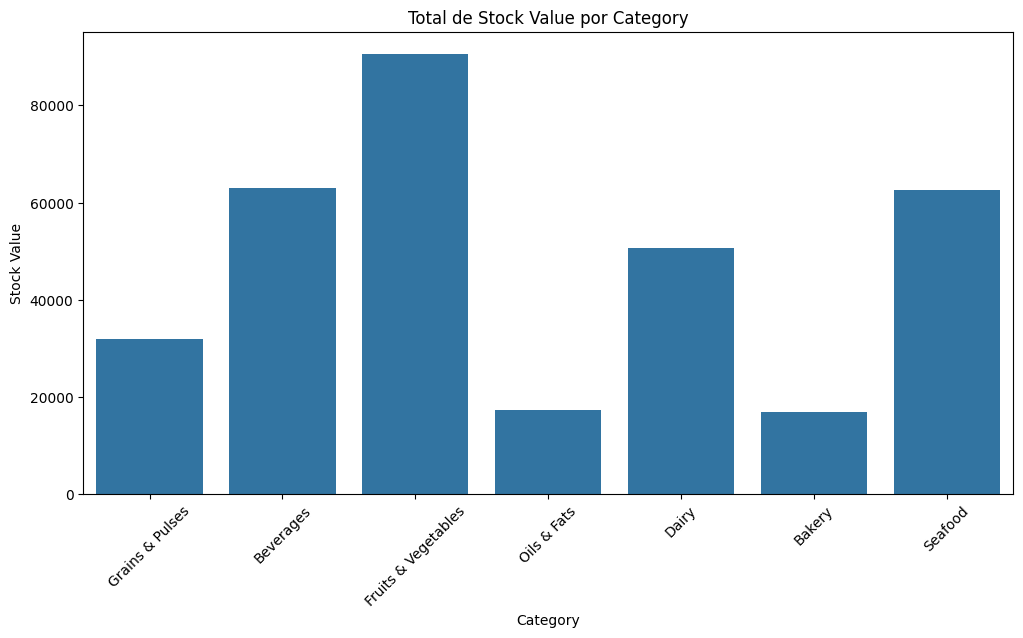

In [40]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Category', y='Stock_Value', estimator=sum, errorbar=None)
plt.xticks(rotation=45)
plt.title("Total de Stock Value por Category")
plt.ylabel("Stock Value")
plt.show()

## Stock Value vs. Sales Volume (Scatter Plot)

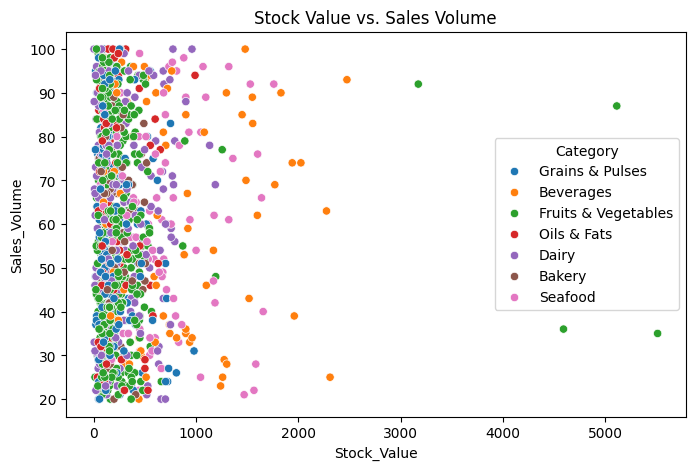

In [41]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Stock_Value', y='Sales_Volume', hue='Category')
plt.title("Stock Value vs. Sales Volume")
plt.show()

## Distribuição de Stock Quantity (Histograma)

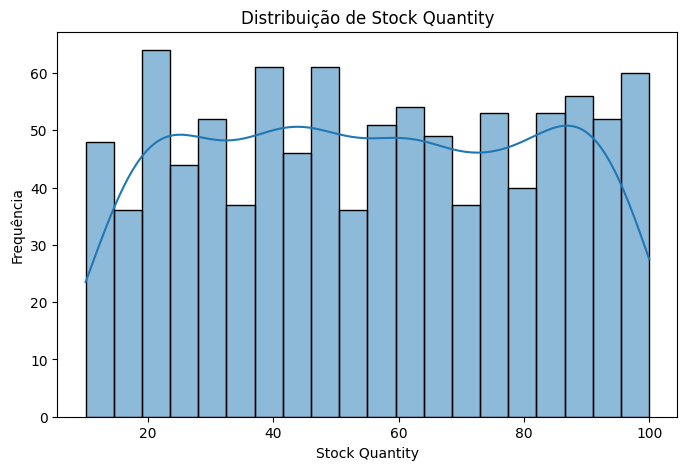

In [42]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Stock_Quantity'], bins=20, kde=True)
plt.title("Distribuição de Stock Quantity")
plt.xlabel("Stock Quantity")
plt.ylabel("Frequência")
plt.show()

### Análise de Stock Age  (Box Plot)

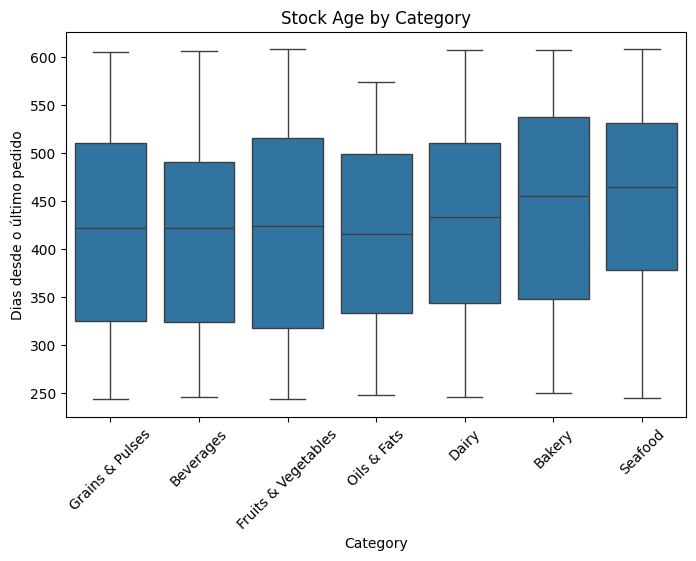

In [43]:
df['Stock_Age'] = (pd.to_datetime('today') - pd.to_datetime(df['Last_Order_Date'])).dt.days

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Category', y='Stock_Age')
plt.xticks(rotation=45)
plt.title("Stock Age by Category")
plt.ylabel("Dias desde o último pedido")
plt.show()

### Distribuição de Status (Gráfico de Barras)

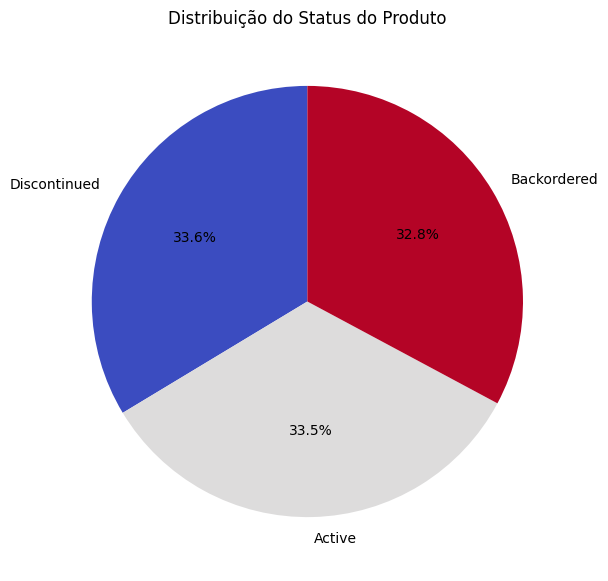

In [44]:
plt.figure(figsize=(7, 7))
df['Status'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='coolwarm')
plt.title("Distribuição do Status do Produto")
plt.ylabel("")
plt.show()

## Análise dos Gráficos

**Total Stock Value por Category (Gráfico de Barras):**
"Fruits & Vegetables" possuem o maior total de stock value, superando significativamente as demais categorias. "Grains & Pulses" e "Oils & Fats" apresentam valores de stock relativamente baixos. "Beverages", "Dairy" e "Seafood" têm valores de estoque moderados.

**Distribuição da Stock Quantity (Histograma):**
A distribuição da stock quantity parece relativamente uniforme, com algumas variações. Existem produtos em toda a faixa de stock quantity.

**Idade do Stock por Category (Box Plot):**
As categories Bakery e “Seafood” apresentam maiores idades medianas de stock (dias desde o último pedido). "Grains & Pulses" tem uma idade mediana de stock menor. Todas as categories exibem uma ampla variação de idades de estoque.

**Distribuição do Status dos Products (Gráfico de Pizza):**
A distribuição do status dos products é relativamente equilibrada, com "Discontinued", "Backordered" e "Active" representando aproximadamente um terço cada do total.

**Valor em Stock vs. Volume de Sales (Gráfico de Dispersão):**
A maioria dos produtos possui valores de stock baixos. Há uma ampla variação de volumes de sales em todos os níveis de valor em stock. Não parece haver uma correlação direta forte entre valor em stock e volume de sales.

## Conclusão sobre os dados analisados

**Desequilíbrio de Stock:** Há um desequilíbrio significativo no valor de stock entre as categories, com Fruits & Vegetables” dominando.

**Products de Alto Valor:** Products específicos, como “Banana”, contribuem de forma significativa para o valor total de stock.

**Vendas vs. Estoque:** O valor em stock não está necessariamente correlacionado com o volume de sales, indicando possíveis ineficiências na gestão do inventário.

**Preocupações com a Idade do Stock:** Algumas categorias, especialmente “Bakery” e “Seafood”, possuem stocks mais antigos, o que pode levar a perdas por vencimento ou obsolescência.

**Status dos Products:** A distribuição equilibrada dos status dos products sugere possíveis problemas na gestão do ciclo de vida dos products.

## Relação com o CodCoz

Baseado nas análises é possível identificar e se prevenir de possíveis problemas que um app que gerencia o estoque de produtos pode ter. Após a análise da estrutura do dataset escolhido, foi possível implementar novos campos relacionados a data de pedidos e "turnover" do inventário no banco de dados final do aplicativo.